<a href="https://colab.research.google.com/github/MANI-WEBDEVE/Learn_AI/blob/main/machine_learning/unsupervised_ML/KMeans_Algorithm/KMeans_Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [133]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

In [134]:
# create the data point through numpy array
X = np.array([[1,2], [2,1], [4,5], [5,4], [8,8], [9,9], [10,3],[12, 11], [15,1], [1,14]])
scaler=StandardScaler()
X_scaler=scaler.fit_transform(X) # normalize the data points




In [135]:
k_means_model=KMeans(
    n_clusters=2,      # K value
    init='k-means++',  # Better than random initialization
    n_init=10,         # 10 baar try karega, best result lega
    max_iter=300,      # Max iterations
    random_state=42    # Reproducible results
)

k_means_model.fit(X_scaler)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [136]:
print("Centroids:", k_means_model.cluster_centers_)
print("Labels:", k_means_model.labels_)  # Har point ka cluster number
print("WCSS:", k_means_model.inertia_)   # Total squared distance

Centroids: [[ 0.89025316  0.14079698]
 [-0.89025316 -0.14079698]]
Labels: [1 1 1 1 0 0 0 0 0 1]
WCSS: 11.876255278139517


In [137]:
# Centroids: [[-0.62985817 -0.62985817]
#  [ 1.25971634  1.25971634]]
# Labels: [0 0 0 0 1 1]
# WCSS: 2.4786885245901633

--------------------
2
--------------------
3
--------------------
2
--------------------
3
--------------------
2
--------------------
2
--------------------
2
--------------------
2
--------------------
2
--------------------
1


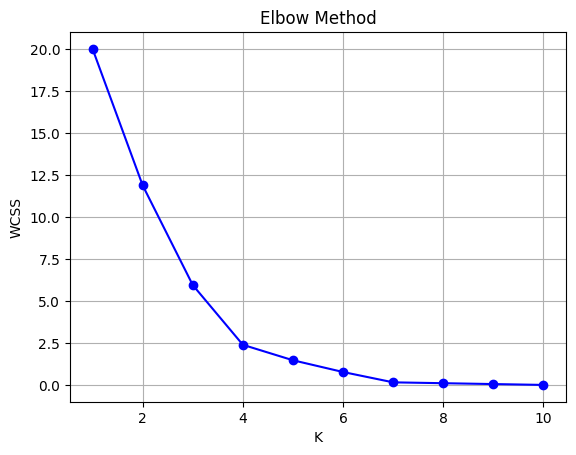

In [138]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaler)
    wcss.append(km.inertia_)
    # print( km.inertia_)
    print('--------------------')
    print(km.n_iter_)

plt.plot(range(1,11), wcss, 'bo-')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

### Code From Scratch how its works

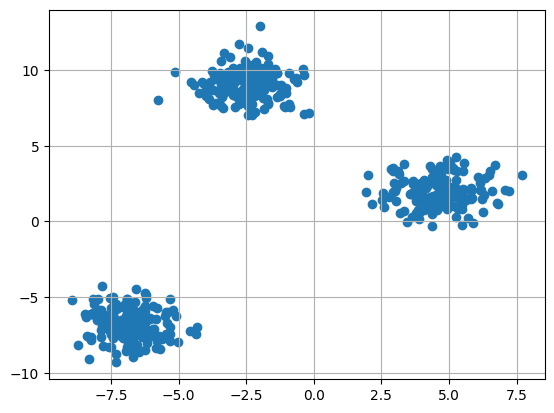

In [139]:
# First import the library and dataset

X, Y = make_blobs(n_samples=500, n_features=2, centers=3, random_state=42)
# X = scaler.transform(X)
plt.grid(True)
plt.scatter(X[:,0], X[:,1])
plt.show()

In [140]:
X.shape

(500, 2)

In [141]:
Y.shape

(500,)

intilizing the centeroid to main concept of K Means cluster

In [142]:
k =3
np.random.seed(32)
clusters={} # empty dictionary

for idx in range(k):
  center=2*(2*np.random.random((X.shape[1])) -1)
  ponits=[]
  cluster={
      'center':center,
      'points': []
  }


  clusters[idx]=cluster


In [143]:
for i in range(k):
  print(i)

0
1
2


In [144]:
clusters

{0: {'center': array([ 1.43555707, -0.50915538]), 'points': []},
 1: {'center': array([0.22051511, 1.8226262 ]), 'points': []},
 2: {'center': array([0.94667839, 1.26482056]), 'points': []}}

In [145]:
X.shape[1]

2

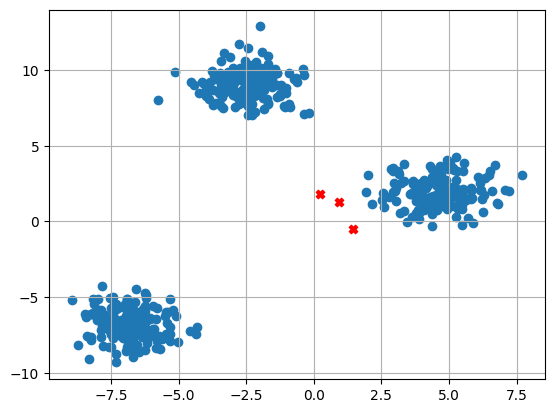

In [146]:
plt.scatter(X[:,0], X[:,1])
plt.grid(True)

for i in clusters:
  center=clusters[i]['center']
  plt.scatter(center[0], center[1], marker='X', c='red')


### Defining Euclidean Distance

In [147]:
def euclidean_distance(p1,p2):
  return np.sqrt(np.sum(p1-p2)**2)

### Assign the cluster

In [148]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]): # shape means (number of data points, features)
                                                       # 500               2        example only
        dist = []

        curr_x = X[idx]           #  X[2] = 34 , X[4] = 400  example to store the current data point to loop interation

        for i in range(k):  # you remeber intialize the centroid point to define the  K value

            dis = euclidean_distance(curr_x,clusters[i]['center'])  # calculate the distance each data point to cluster center / cluster[center] means = [0.0987, 9.987]
            dist.append(dis)
        curr_cluster = np.argmin(dist) # this line return the minmum value of index our distance array
        clusters[curr_cluster]['points'].append(curr_x) # cluster[0]['points'].append(curr_x)  curr_x = [1.2332, 0.3333]
                                                        # we have three cluster [0], [1], [2]
    return clusters

In [149]:
clusters


{0: {'center': array([ 1.43555707, -0.50915538]), 'points': []},
 1: {'center': array([0.22051511, 1.8226262 ]), 'points': []},
 2: {'center': array([0.94667839, 1.26482056]), 'points': []}}

In [150]:
for i in range(k):
  print(clusters[i]['center'])

[ 1.43555707 -0.50915538]
[0.22051511 1.8226262 ]
[0.94667839 1.26482056]


In [151]:
for i in range(k):
  print(euclidean_distance( [-0.87678632,  7.58414475],clusters[i]['center']))

5.7809567409267215
4.664217122038543
4.495859481505182


In [152]:
clusters

{0: {'center': array([ 1.43555707, -0.50915538]), 'points': []},
 1: {'center': array([0.22051511, 1.8226262 ]), 'points': []},
 2: {'center': array([0.94667839, 1.26482056]), 'points': []}}

In [153]:
# update the centroid position

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        # print(points)

        if points.shape[0] > 0:
            print('hello',points.shape[0])
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center

            clusters[i]['points'] = []
    return clusters

In [154]:
np.mean(166)

np.float64(166.0)

In [155]:
# Predict the values

def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(euclidean_distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [156]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

hello 166
hello 334


In [157]:
for i in clusters:
  print(clusters[i]['points'])


[]
[]
[]


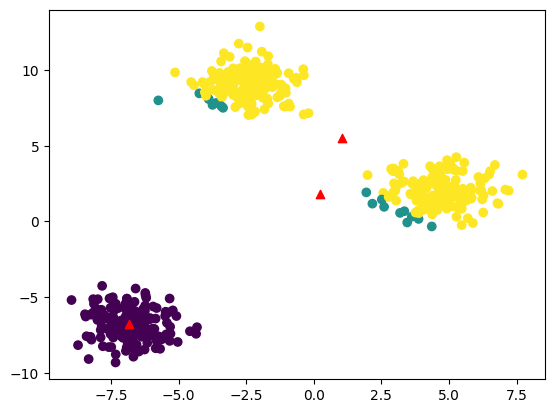

In [158]:
plt.scatter(X[:,0],X[:,1],c=pred )
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

In [161]:
# Silhouette score code
from sklearn.metrics import silhouette_score
score = silhouette_score(X, pred)
print("Silhouette Score:", score)  # > 0.5 = good

Silhouette Score: 0.33097581049474906
